# House Prices: Advanced Regression Techniques

#### Walusungu Nyirenda

The goal is to predict `SalePrice` for every house in `test.csv`, using `train.csv` to
learn from. `test.csv` has no `SalePrice` column, that's what gets submitted to Kaggle.

A detail that matters throughout this notebook: any value we compute for filling in
missing data or for scaling (a median, a mode, a "typical" value for a neighborhood)
gets computed from `train.csv` only, and then applied to both `train.csv` and
`test.csv`. If we let the test set influence those values, we'd be leaking information
about houses we're not supposed to know the price of yet into the training process,
which would make our validation score look better than it really is.

Rough plan:
1. Load the data and understand the target
2. Deal with missing values, using train-only statistics
3. Fix a column that's numeric but shouldn't be treated that way
4. Encode categorical columns
5. Try a simple model, then a stronger one, and compare them
6. Predict on the test set and write `submission.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 1. Loading the data and understanding the target

`train.csv` has 1460 houses with a known sale price, `test.csv` has 1459 houses we
need to predict for. Both files describe the same 79 features (lot size, quality
ratings, neighborhood, and so on), `train.csv` just has the extra `SalePrice` column.

In [ ]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print('train:', df_train.shape)
print('test :', df_test.shape)
df_train.head()

train: (1460, 81)
test : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Why we train on `log1p(SalePrice)`

House prices are not symmetric, most houses sell for a moderate amount and a smaller
number sell for a lot, so the raw distribution has a long tail on the right. The
competition also scores submissions using the log of the price rather than the price
itself, so a model that's accurate in dollar terms on expensive houses isn't
necessarily the one that scores best. Taking `log1p` (log of 1 + price, so we don't
hit `log(0)`) makes the distribution closer to a normal bell curve and lines our
training target up with how the model will actually be judged. We reverse this with
`expm1` right before writing the final predictions, so `submission.csv` still contains
real dollar amounts.

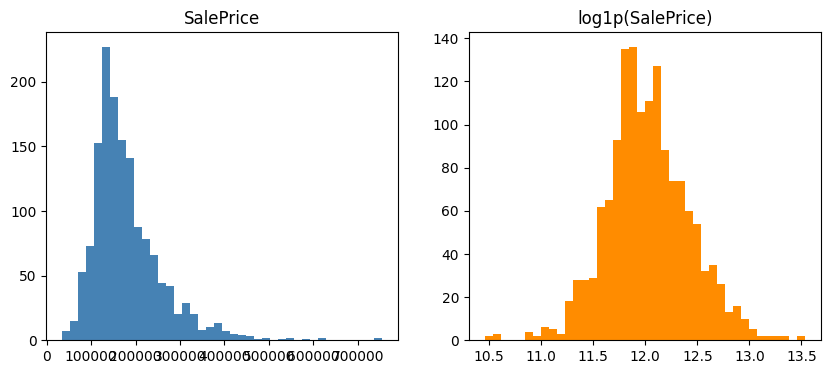

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df_train['SalePrice'], bins=40, color='steelblue')
ax[0].set_title('SalePrice')

ax[1].hist(np.log1p(df_train['SalePrice']), bins=40, color='darkorange')
ax[1].set_title('log1p(SalePrice)')
plt.show()

### A first look at what drives price

Before touching missing values or encoding, it's worth checking which of the numeric
columns already line up with `SalePrice` on their own. This only looks at linear
relationships between two numeric columns at a time, so it won't tell us anything
about the categorical columns (like `Neighborhood`) or about features that only matter
in combination with others, but it's a quick sanity check that the data behaves the
way you'd expect a house price to behave.

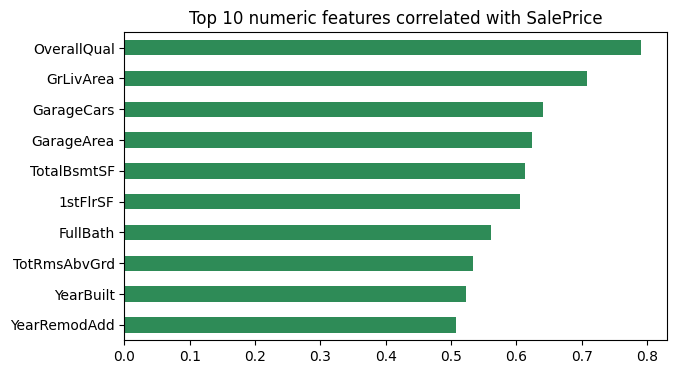

In [ ]:
top_corr = df_train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)[1:11]

plt.figure(figsize=(7, 4))
top_corr.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 numeric features correlated with SalePrice')
plt.show()

## 2. Missing values

`data_description.txt` explains what each column means, and reading through it, most
of the missing values in this dataset are not actually unknown information. A blank
`PoolQC` means the house has no pool, a blank `GarageType` means it has no garage, and
so on for a whole group of basement- and garage-related columns. Filling those with
the column median or dropping the rows would throw away a real, meaningful signal
("no garage" is informative). A much smaller number of columns have values that are
genuinely just missing, and those get filled with a median or the most common value
instead.

We write one function, `fill_missing`, that takes a dataframe and a set of
already-computed reference statistics and applies them. The statistics themselves
(the neighborhood medians, the most common category per column) are computed from
`df_train` a single time, below, and passed into the function for both `df_train` and
`df_test`. This keeps the "learn from training data" and "apply everywhere" steps
clearly separate, and means the function itself has no dependency on which dataframe
it's being called on.

In [ ]:
no_feature_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType',
                    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
zero_cols = ['GarageYrBlt', 'GarageCars', 'GarageArea', 'MasVnrArea',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']
mode_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
             'Electrical', 'KitchenQual', 'Functional', 'SaleType']


def fill_missing(df, lot_medians, overall_lot_median, modes):
    df = df.copy()
    df[no_feature_cols] = df[no_feature_cols].fillna('None')
    df[zero_cols] = df[zero_cols].fillna(0)
    df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(lot_medians))
    df['LotFrontage'] = df['LotFrontage'].fillna(overall_lot_median)

    df[mode_cols] = df[mode_cols].fillna(pd.Series(modes))
    return df

Now we compute the reference statistics from `df_train` only, and use them to clean
both `df_train` and `df_test`.

In [ ]:
lot_medians = df_train.groupby('Neighborhood')['LotFrontage'].median()
overall_lot_median = df_train['LotFrontage'].median()
modes = {col: df_train[col].mode()[0] for col in mode_cols}

df_train = fill_missing(df_train, lot_medians, overall_lot_median, modes)
df_test = fill_missing(df_test, lot_medians, overall_lot_median, modes)

print('missing in train:', df_train.isnull().sum().sum())
print('missing in test :', df_test.isnull().sum().sum())

missing in train: 0
missing in test : 0


## 3. `MSSubClass` is a category, not a number

`MSSubClass` stores a building-type code, values like 20, 60, and 90, but these codes
don't have any numeric meaning. A `90` isn't three times a `30`, it's just a different
label for a different kind of dwelling. If we leave this column as-is, a model would
wrongly assume the codes are ordered or that the distance between them means
something. Converting it to text fixes this, since it will then be one-hot encoded
along with the rest of the genuinely categorical columns instead of being treated as
a number.

In [ ]:
df_train['MSSubClass'] = df_train['MSSubClass'].astype(str)
df_test['MSSubClass'] = df_test['MSSubClass'].astype(str)

## 4. Encoding the categorical columns

Two different situations here, and they call for two different encodings:

- **Quality and condition columns** (`ExterQual`, `KitchenQual`, `BsmtCond`, and
  several others) all use the same underlying scale: poor is worse than fair, which is
  worse than average, and so on up to excellent. That's a real order, so mapping each
  one to a number by hand preserves it. A plain one-hot encoding would throw that order
  away and force the model to relearn "`Gd` is better than `Fa`" from scratch, using up
  more columns to do it.
- A few other columns (`BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`, `GarageFinish`)
  are ordinal too, but each uses its own scale rather than the poor-to-excellent one.
- Everything else left as text (`Neighborhood`, `SaleType`, `MSSubClass` now that we've
  converted it, and so on) has no natural order, so those get one-hot encoded instead.

The mappings below are fixed, domain knowledge about what the categories mean, not
anything learned from the data, so there's no train/test leakage concern in applying
them to both dataframes directly.

In [ ]:
quality_scale = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

ordinal_maps = {col: quality_scale for col in quality_cols}
ordinal_maps['BsmtExposure'] = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
ordinal_maps['BsmtFinType1'] = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
ordinal_maps['BsmtFinType2'] = ordinal_maps['BsmtFinType1']
ordinal_maps['GarageFinish'] = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}


def ordinal_encode(df):
    df = df.copy()
    for col, mapping in ordinal_maps.items():
        df[col] = df[col].map(mapping)
    return df


df_train = ordinal_encode(df_train)
df_test = ordinal_encode(df_test)

### One-hot encoding, and keeping train and test lined up

A common shortcut is to stack `train` and `test` into one dataframe before calling
`pd.get_dummies`, so both sets automatically end up with identical columns. We avoid
that here, since it's easy to lose track of what came from where once the two are
merged, and it also means any later step, however small, that touches the combined
frame could quietly use test-set information without anyone noticing.

Instead we one-hot encode `df_train` and `df_test` separately, and then explicitly
line up `X_test`'s columns to match `X_train`'s with `reindex`. If a category shows up
in `df_test` but was never seen in `df_train`, `reindex` drops it, since the model has
no way to have learned anything about it anyway. If a category from training simply
doesn't appear in the test set, `reindex` adds that column back in as all zeros, which
is exactly what "this house is not in that category" should look like.

In [ ]:
y = np.log1p(df_train['SalePrice'])

X = pd.get_dummies(df_train.drop(columns=['Id', 'SalePrice']), drop_first=True)
X_test = pd.get_dummies(df_test.drop(columns=['Id']), drop_first=True)

X_test = X_test.reindex(columns=X.columns, fill_value=0)

print('X:     ', X.shape)
print('X_test:', X_test.shape)

X:      (1460, 227)
X_test: (1459, 227)


## 5. Choosing a model

We hold out 20% of `df_train` to check how well a model generalizes before it ever
sees the real test set. Everything from here on is scored using that held-out slice.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=7)

### A baseline first

Before reaching for a more complex model, it's worth having a simple one to compare
against, otherwise there's no way to tell whether the extra complexity is actually
earning its keep. Linear regression is a reasonable floor: fast, no tuning required,
and a fair test of how far a purely linear combination of the encoded features can get.

In [ ]:
baseline = LinearRegression().fit(X_train, y_train)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline.predict(X_val)))
print(f'Linear regression RMSE: {baseline_rmse:.4f}')

Linear regression RMSE: 0.2311


### A random forest

A random forest fits many decision trees on different random slices of the data and
features, then averages their predictions. Two things make it a good next step up from
linear regression here: it can pick up interactions between features on its own (for
example, `GrLivArea` probably matters differently depending on `Neighborhood`, without
us having to build that combination by hand), and it needs very little tuning to get a
solid result, unlike a gradient-boosted model, which tends to need more careful
tuning of the learning rate and tree count to avoid overfitting.

In [ ]:
forest = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=2,
    random_state=7,
    n_jobs=-1,
)
forest.fit(X_train, y_train)

forest_rmse = np.sqrt(mean_squared_error(y_val, forest.predict(X_val)))
print(f'Random forest RMSE: {forest_rmse:.4f}')

Random forest RMSE: 0.1321


The random forest comes out well ahead of the linear baseline, so that's the model
we'll use for the final predictions.

### Which features is it actually relying on?

`feature_importances_` tells us how much each feature reduced prediction error across
all the trees in the forest, averaged together. It's a rough guide rather than a
precise ranking, but it's a useful check that the model is leaning on features that
make intuitive sense for a house price, rather than something spurious.

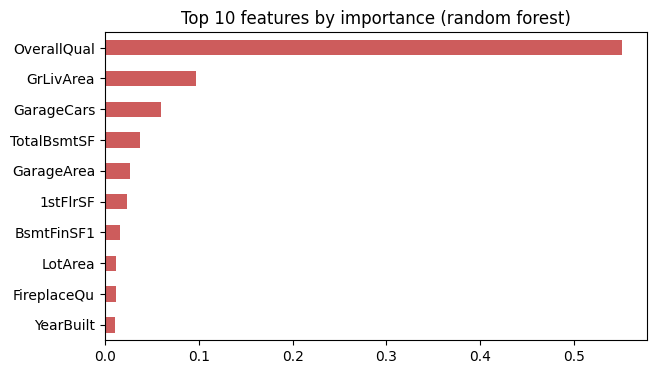

In [ ]:
top_features = pd.Series(forest.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(7, 4))
top_features.sort_values().plot(kind='barh', color='indianred')
plt.title('Top 10 features by importance (random forest)')
plt.show()

## 6. Final predictions

The 80/20 split was only there to let us compare models honestly. Now that we've
picked the random forest, we refit it on all of `df_train`, holding nothing back,
since more training data generally means a better model, and we no longer need a
validation slice, we already used one to make the model choice. We then predict on
`X_test` and undo the `log1p` transform with `expm1` to get the predictions back into
dollars before writing them out.

In [ ]:
final_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=2,
    random_state=7,
    n_jobs=-1,
).fit(X, y)

predictions = np.expm1(final_model.predict(X_test))

submission = pd.DataFrame({'Id': df_test['Id'], 'SalePrice': predictions})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,123961.535082
1,1462,152495.850120
2,1463,180476.280891
3,1464,181895.616292
4,1465,195747.143118


## Summary

- Missing values were split into "doesn't have this feature" (filled with `None`/`0`)
  and "actually missing" (filled with a median or mode), and every fill value was
  computed from `df_train` only, then applied to both `df_train` and `df_test`, to
  avoid leaking test-set information into the training process.
- `MSSubClass` looks numeric but is really a category code, so it was converted to
  text before encoding.
- Quality-scale columns were ordinal encoded by hand, using the real order of the
  categories, and everything else was one-hot encoded, with `df_test`'s columns
  explicitly lined up against `df_train`'s afterwards rather than relying on encoding
  both together.
- A linear regression baseline gave us a number to judge the random forest against,
  the forest won by a clear margin, and was used for the final predictions in
  `submission.csv`.